## 1. What this notebook computes

The pairing theorems T1 and T2 are statements about the Lagrangian, the field
equations, the energy-momentum tensor and the current of the two fields
dirac16complex (anticommuting, Grassmann components) and dirac16complex00
(commuting components). Notebook 18a proved the matrix facts behind them. This
notebook proves the theorems themselves, in the author's primordial
gravitational field, as exact identities computed with sympy:

1. It builds the author's metric with an ARBITRARY history $a_4(x_4)$ (the three
   extra times $x_5, x_6, x_7$ deflate exponentially as $a_4$ grows), its
   diagonal vielbein and its canonical spin connection, and checks the connection.
2. It writes every quantity of the theory as a polynomial in the values of the
   field and of its first derivatives at a point (the *first jet*), with
   commuting components and with Grassmann components.
3. **T1**: it proves $\mathcal{L}_{m,\lambda}[\Gamma\Psi] =
   -\mathcal{L}_{-m,-\lambda}[\Psi]$, the map of the field equations, $T_{\mu\nu}
   \to -T_{\mu\nu}$ and $J^\mu \to -J^\mu$, so that the pair has zero total
   energy-momentum and current; and it shows with *negative controls* that the
   coupling $\lambda$ must change sign too.
4. **T2**: it proves that the reflection of the hidden direction across the
   brane $z = \pi/2$, with $\Psi \to \gamma^{(x_8)}\Psi$, maps a solution with
   $(-m, \lambda)$ to a solution with $(m, \lambda)$, reverses $S$ and keeps the
   energy-momentum tensor and the current (pulled back, not reversed).

Every result is compared with the checks of the two Revision pairing reports
(the sympy report and the Wolfram report), and five figures show what cancels and
what does not.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 18b (T1 and T2 proved symbolically in the author's deflating metric) is the file
`Revision/textbook/notebooks/18b_t1_t2_symbolic.ipynb` of the repository Dirac_claude.
With sympy it builds the author's metric with an arbitrary history a4(x4) of the three
exponentially deflating extra times, its diagonal vielbein and its canonical spin
connection, and checks the connection (antisymmetry, the vielbein postulate, its nonzero
components, gamma^mu Omega_mu = 3 H gamma^(x8) with the deflation terms cancelling). It
then writes the Lagrangian, the field equation, the energy-momentum tensor and the
current of the two fields on the first jet, with commuting components (dirac16complex00)
and with Grassmann components (dirac16complex), and proves as exact polynomial identities
the pairing theorem T1 (L_m,lambda of Gamma Psi = minus L_-m,-lambda of Psi, the field
equations, T and J reversed, the pair sums zero, a general cubic potential, a random
general field) with its negative controls, and the pairing theorem T2 across the Z2
mirror z to pi minus z (L to plus L_-m,lambda, S reversed, T and J pulled back, not
reversed). It reproduces 35 checks of the sympy pairing report and the monomial counts
and checks of the Wolfram pairing report, and draws five teaching figures. It needs a
computer with Windows 11, macOS or Linux, an internet connection for the installation,
the program Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5)
with these packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0,
matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0
and nbconvert 7.16.6. The notebook itself imports numpy, sympy and matplotlib; the other
packages run Jupyter, the program that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 18b_t1_t2_symbolic.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 2 minutes on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 18b_t1_t2_symbolic.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
18b_t1_t2_symbolic.ipynb` (in the same folder, without running the cells again) to read
the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/18b.captions.json`
- `Revision/textbook/figures/18b_1_connection_history.png`
- `Revision/textbook/figures/18b_2_lagrangian_cancellation.png`
- `Revision/textbook/figures/18b_3_emt_signs.png`
- `Revision/textbook/figures/18b_4_mirror_metric.png`
- `Revision/textbook/figures/18b_5_mirror_candidates.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS every figure file of this notebook exists
    ALL 20 CHECKS PASSED (notebook 18b)

and the notebook must show 5 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/18b_t1_t2_symbolic.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4. If the environment is active and the message stays, the programs
  jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
  programs (`python -m jupyter` does not help then: it has to find the same programs).
  Start them through Python itself, in the folder of the notebook: the first command
  below does what `jupyter lab` does, the second what the headless command does:

      python -m jupyterlab 18b_t1_t2_symbolic.ipynb
      python -m nbconvert --execute --inplace 18b_t1_t2_symbolic.ipynb

- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" for gammas.json or one of the pairing reports: the notebook reads
  four files of the repository; it must be opened inside the folder
  Revision/textbook/notebooks of a complete copy of the repository. Clone the repository
  again and open the notebook there.
- a cell runs for several minutes: the symbolic checks take about a minute and a half in
  all on the computer on which the book was built; on a slow computer they may take five
  minutes. Wait for the PASS lines; the star in the margin of a running cell turns into a
  number when it ends.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 18b (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 18b (T1 and T2 proved symbolically in the author's deflating metric) is the
# file Revision/textbook/notebooks/18b_t1_t2_symbolic.ipynb of the repository
# Dirac_claude. With sympy it builds the author's metric with an arbitrary history a4(x4)
# of the three exponentially deflating extra times, its diagonal vielbein and its
# canonical spin connection, and checks the connection (antisymmetry, the vielbein
# postulate, its nonzero components, gamma^mu Omega_mu = 3 H gamma^(x8) with the
# deflation terms cancelling). It then writes the Lagrangian, the field equation, the
# energy-momentum tensor and the current of the two fields on the first jet, with
# commuting components (dirac16complex00) and with Grassmann components (dirac16complex),
# and proves as exact polynomial identities the pairing theorem T1 (L_m,lambda of Gamma
# Psi = minus L_-m,-lambda of Psi, the field equations, T and J reversed, the pair sums
# zero, a general cubic potential, a random general field) with its negative controls,
# and the pairing theorem T2 across the Z2 mirror z to pi minus z (L to plus L_-m,lambda,
# S reversed, T and J pulled back, not reversed). It reproduces 35 checks of the sympy
# pairing report and the monomial counts and checks of the Wolfram pairing report, and
# draws five teaching figures. It needs a computer with Windows 11, macOS or Linux, an
# internet connection for the installation, the program Git, and Python 3.12 or newer
# (the notebooks were built with Python 3.14.5) with these packages at exactly these
# versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab
# 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The
# notebook itself imports numpy, sympy and matplotlib; the other packages run Jupyter,
# the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 18b_t1_t2_symbolic.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 2
# minutes on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 18b_t1_t2_symbolic.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 18b_t1_t2_symbolic.ipynb (in the same folder, without running the cells again) to read
# the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/18b.captions.json
# - Revision/textbook/figures/18b_1_connection_history.png
# - Revision/textbook/figures/18b_2_lagrangian_cancellation.png
# - Revision/textbook/figures/18b_3_emt_signs.png
# - Revision/textbook/figures/18b_4_mirror_metric.png
# - Revision/textbook/figures/18b_5_mirror_candidates.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS every figure file of this notebook exists
#     ALL 20 CHECKS PASSED (notebook 18b)
#
# and the notebook must show 5 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/18b_t1_t2_symbolic.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4. If the environment is active and the message stays, the programs
#   jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
#   programs (python -m jupyter does not help then: it has to find the same programs).
#   Start them through Python itself, in the folder of the notebook: the first command
#   below does what jupyter lab does, the second what the headless command does:
#     python -m jupyterlab 18b_t1_t2_symbolic.ipynb
#     python -m nbconvert --execute --inplace 18b_t1_t2_symbolic.ipynb
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" for gammas.json or one of the pairing reports: the notebook reads
#   four files of the repository; it must be opened inside the folder
#   Revision/textbook/notebooks of a complete copy of the repository. Clone the
#   repository again and open the notebook there.
# - a cell runs for several minutes: the symbolic checks take about a minute and a half
#   in all on the computer on which the book was built; on a slow computer they may take
#   five minutes. Wait for the PASS lines; the star in the margin of a running cell turns
#   into a number when it ends.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "18b"  # this notebook: chapter 18, example b


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 18b complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Metric, vielbein**: the metric $g_{\mu\nu}$ measures lengths and times; a
  *vielbein* $e^a{}_\mu$ writes it as $g_{\mu\nu} = \sum_a\eta_{aa}e^a{}_\mu
  e^a{}_\nu$ with $\eta = \mathrm{diag}(+1, +1, +1, -1, -1, -1, -1, +1)$. For the
  author's diagonal metric $e^a{}_\mu = f_\mu\delta^a_\mu$ with
  $f_\mu = \sqrt{|g_{\mu\mu}|}$.
- **Christoffel symbols** $\Gamma^\nu{}_{\mu\lambda}$: the numbers (functions)
  built from the first derivatives of the metric that say how the coordinate
  directions turn from point to point.
- **Canonical spin connection** $\omega_{\mu ab}$: the connection that makes the
  gammas $\gamma^\mu = e^\mu{}_a\gamma^{(a)}$ covariantly constant (the *vielbein
  postulate*); it is antisymmetric in $a, b$. $\Omega_\mu =
  \frac12\sum_{a,b}\omega_{\mu ab}S^{ab}$ enters the covariant derivative
  $D_\mu\Psi = \partial_\mu\Psi + \Omega_\mu\Psi$.
- **Jet**: at one point, the 16 components $\Psi_A$, their complex conjugates
  $\Psi_A^*$, and the $8 \times 16$ first derivatives $\partial_\mu\Psi_A$ and
  $\partial_\mu\Psi_A^*$: 288 numbers. Every quantity of this notebook at that
  point is a polynomial in these 288 numbers, with coefficients that depend on the
  point.
- **Generator, monomial**: the notebook treats each of the 288 jet values as a
  symbol, a *generator*; a *monomial* is a product of generators, and a
  polynomial is a sum of monomials times coefficients.
- **Grassmann generators**: symbols that anticommute, $\theta_1\theta_2 =
  -\theta_2\theta_1$, so $\theta_1\theta_1 = 0$. They model the anticommuting
  components of dirac16complex.
- **Identity in the jets**: a polynomial whose every coefficient is zero. It is
  zero for EVERY value of the jet, that is, for every field at every point,
  whether the field solves the field equations or not (*off shell*). An identity
  off shell holds in particular for solutions (*on shell*).
- **Euler-Lagrange expression**: $\partial\mathcal{L}/\partial\Psi^*_A -
  \sum_\mu\partial_\mu\big(\partial\mathcal{L}/\partial(\partial_\mu\Psi^*_A)\big)$;
  the field equations say it is zero.
- **Negative control**: a computation that must FAIL; it shows that the test can
  detect a wrong statement.
- **Isometry**: a change of coordinates that does not change the metric.
- **Patch, mirror patch, brane**: the author's coordinate $z = 6Hx_8$ runs over
  the *patch* $0 < z < \pi/2$. The map $z \to \pi - z$ takes it to the *mirror
  patch* $\pi/2 < z < \pi$; the surface $z = \pi/2$ between them is the *brane*,
  where $g_{88} = \cot^2 z = 0$. Gluing the mirror patch to the patch there is
  the Z2 construction, an ASSUMPTION of the Revision record.

## 4. The physical and mathematical situation

**The metric.** In the author's coordinates ($x_1, x_2, x_3$ 3-space, $x_4$ the
time, $x_5, x_6, x_7$ the extra times, $x_8$ hidden, $z = 6Hx_8$)

$$ds^2 = e^{2a_4}\sin^{1/3}z\,(dx_1^2 + dx_2^2 + dx_3^2) - dx_4^2
- e^{-2a_4}\sin^{1/3}z\,(dx_5^2 + dx_6^2 + dx_7^2) + \cot^2 z\,dx_8^2 ,$$

with $a_4 = a_4(x_4)$. As $a_4$ grows, 3-space inflates ($e^{a_4}$) and the three
extra times deflate exponentially ($e^{-a_4}$). The vielbein factors are
$f_1 = f_2 = f_3 = e^{a_4}\sin^{1/6}z$, $f_4 = 1$, $f_5 = f_6 = f_7 =
e^{-a_4}\sin^{1/6}z$, $f_8 = \cot z$, and $\sqrt{|g|} = f_1f_2\cdots f_8 =
\cos z$. The notebook keeps $a_4$ as an unknown function of $x_4$, so every result
holds for every history, deflating or not.

**The theory.** With $\bar\Psi = \Psi^\dagger C$, $S = \bar\Psi\Psi$ and
$D_\mu\bar\Psi = \partial_\mu\bar\Psi - \bar\Psi\Omega_\mu$,

$$\mathcal{L}_{m,\lambda} = \sqrt{|g|}\Big[\tfrac12\big(\bar\Psi\gamma^\mu
D_\mu\Psi - (D_\mu\bar\Psi)\gamma^\mu\Psi\big) - mS - \tfrac{\lambda}{2}S^2\Big],
\qquad E_{m,\lambda} = \gamma^\mu D_\mu\Psi - (m + \lambda S)\Psi ,$$

$$T_{\mu\nu} = \tfrac14\big(\bar\Psi\gamma_\mu D_\nu\Psi + \bar\Psi\gamma_\nu
D_\mu\Psi - (D_\mu\bar\Psi)\gamma_\nu\Psi - (D_\nu\bar\Psi)\gamma_\mu\Psi\big)
- g_{\mu\nu}\mathcal{L}/\sqrt{|g|},\qquad J^\mu = i\bar\Psi\gamma^\mu\Psi .$$

The field equation is $E_{m,\lambda} = 0$. $T_{\mu\nu}$ and $J^\mu$ are written
exactly as in the sympy pairing report of the Revision record; another overall
sign or factor changes nothing below, because every statement is of the form
$T' = \pm T$, $J' = \pm J$. (In this convention the energy density of the theory
record is $\rho = -T_{x_4x_4}$.)

**Why a polynomial identity in the jet is a proof.** Every quantity above, at a
point, is a polynomial in the 288 jet values whose coefficients are functions of
$x_4$ and $z$ (through $a_4$, $a_4' = da_4/dx_4$, $\sin z$, $\cot z$, $H$). If
the polynomial $\mathcal{L}_{m,\lambda}[\Gamma\Psi] + \mathcal{L}_{-m,-\lambda}
[\Psi]$ has only zero coefficients, it vanishes for every field, at every point,
for every history $a_4$: that IS the theorem. For dirac16complex the jet values
are Grassmann generators; the same computation in an algebra of anticommuting
symbols proves the theorem for that field.

## 5. The gamma matrices as exact sympy matrices

The next cell imports sympy and numpy, defines the helpers that read the Revision
records (`reproduces` passes only when the notebook's own result holds AND every
named check of the named report has the verdict PASS), reads the author's gamma
matrices and builds $C$, $\Gamma$ and $S^{ab} = \frac14[\gamma^{(a)},
\gamma^{(b)}]$ as exact sympy matrices (whole numbers and halves, no rounding).

In [2]:
import itertools  # all combinations of signs
import random  # Python's random numbers with a fixed seed (the random field)

import numpy as np  # numbers for the figures
import sympy as sp  # exact symbolic algebra

GAMMAS = "Revision/algebra/gammas.json"
PY = "Revision/pairing/reports/python-pairing.json"  # the sympy verifier's report
WL = "Revision/pairing/reports/wolfram-pairing.json"  # the Wolfram verifier's report
PARAMETERS = "Revision/kohn_sham/results/parameters.json"


def read_json(relative):
    """Read a JSON file of the repository (a Revision record)."""
    return json.loads(repository_file(relative).read_text(encoding="utf-8"))


RECORDS = {PY: read_json(PY), WL: read_json(WL)}


def recorded(report_file, name):
    """The recorded entry (verdict and detail) of the check name of a report."""
    for entry in RECORDS[report_file]["checks"]:
        if entry["name"] == name:
            return entry
    return {"verdict": "MISSING", "detail": ""}


def reproduces(condition, name, *sources):
    """check(condition, name), which also requires every named check of every
    source (report_file, [check names]) to have the recorded verdict PASS."""
    ok = all(recorded(f, n)["verdict"].upper() == "PASS"
             for f, names in sources for n in names)
    text = "; ".join(f"{f}, check {', '.join(names)}" for f, names in sources)
    check(condition and ok, name, record=text)


fixture = read_json(GAMMAS)
G = {a: sp.Matrix(fixture["gamma"][a - 1]) for a in range(1, 9)}  # gamma^(x_a)
ETA = {a: int(fixture["eta"][a - 1]) for a in range(1, 9)}
I16 = sp.eye(16)
C = G[8] * G[1] * G[2] * G[3]  # the four space-like gammas
GAM = G[8] * G[1] * G[2] * G[3] * G[4] * G[5] * G[6] * G[7]  # the chirality Gamma
SAB = {(a, b): (G[a] * G[b] - G[b] * G[a]) / 4  # the generators S^ab
       for a in range(1, 9) for b in range(1, 9)}
check(all(G[a] * G[b] + G[b] * G[a] == (2 * ETA[a] if a == b else 0) * I16
          for a in range(1, 9) for b in range(1, 9))
      and GAM == sp.diag(*([-1] * 8 + [1] * 8)),
      "eight real 16 x 16 gammas with the Clifford relations; Gamma = diag(-I8, I8)")

PASS eight real 16 x 16 gammas with the Clifford relations; Gamma = diag(-I8, I8)


## 6. The author's metric and its canonical spin connection

The next cell defines the symbols: the time $x_4$, the hidden angle $z$, the
author's constant $H$, the mass $m$, the coupling $\lambda$ and the unknown
function $a_4(x_4)$. A derivative along $x_8$ is a derivative along $z$ times
$6H$ (because $z = 6Hx_8$); nothing depends on $x_1, x_2, x_3, x_5, x_6, x_7$.

The class `Geometry` then computes, for the diagonal vielbein with the factors
$f_\mu$ of section 4 (with $f_8 = s_8\cot z$, where the sign $s_8 = +1$ on the
patch and $s_8 = -1$ on the mirror patch keeps $f_8$ positive):

- the metric $g_{\mu\mu} = \eta_{\mu\mu}f_\mu^2$ and $\sqrt{|g|} = f_1\cdots f_8$;
- the Christoffel symbols of a diagonal metric,
  $\Gamma^\nu{}_{\mu\lambda} = \frac{1}{2g_{\nu\nu}}\big(\delta_{\nu\lambda}
  \partial_\mu g_{\nu\nu} + \delta_{\nu\mu}\partial_\lambda g_{\nu\nu} -
  \delta_{\mu\lambda}\partial_\nu g_{\mu\mu}\big)$;
- the canonical spin connection $\omega_\mu{}^a{}_b = e^a{}_\nu\big(\partial_\mu
  e^\nu{}_b + \Gamma^\nu{}_{\mu\lambda}e^\lambda{}_b\big)$ with the inverse
  vielbein $e^\nu{}_b = \delta^\nu_b/f_b$, lowered to $\omega_{\mu ab} =
  \eta_{aa}\,\omega_\mu{}^a{}_b$;
- $\Omega_\mu = \frac12\sum_{a,b}\omega_{\mu ab}S^{ab}$, the curved gammas
  $\gamma^\mu = \gamma^{(\mu)}/f_\mu$ and $\gamma_\mu = g_{\mu\mu}\gamma^\mu$.

Every expression is simplified exactly by sympy.

In [3]:
x4, z, H = sp.symbols("x4 z H", real=True)
m, lam = sp.symbols("m lambda", real=True)
a4 = sp.Function("a4")(x4)  # the history: any function of the time x4


def d(expr, mu):
    """The derivative of a coefficient along the coordinate x_mu."""
    if mu == 4:
        return sp.diff(expr, x4)
    if mu == 8:
        return 6 * H * sp.diff(expr, z)  # z = 6 H x8
    return sp.Integer(0)  # nothing depends on x1, x2, x3, x5, x6, x7


class Geometry:
    """The author's metric with the diagonal vielbein; s8 = +1 on the patch,
    s8 = -1 on the mirror patch (then f8 = -cot z > 0)."""

    def __init__(self, s8):
        up, down = sp.exp(a4), sp.exp(-a4)  # inflating and deflating factors
        s6 = sp.sin(z) ** sp.Rational(1, 6)
        f = {1: up * s6, 2: up * s6, 3: up * s6, 4: sp.Integer(1),
             5: down * s6, 6: down * s6, 7: down * s6, 8: s8 * sp.cot(z)}
        self.f = f
        self.g = {mu: ETA[mu] * f[mu] ** 2 for mu in f}  # g_mu mu
        self.sqrtg = sp.simplify(sp.Mul(*f.values()))  # sqrt|g|
        g = self.g
        self.chr = {}  # Christoffel symbols Gamma^nu_(mu lambda)
        for nu, mu, la in itertools.product(range(1, 9), repeat=3):
            v = 0
            if nu == la:
                v += d(g[nu], mu)
            if nu == mu:
                v += d(g[nu], la)
            if mu == la:
                v -= d(g[mu], nu)
            self.chr[nu, mu, la] = sp.simplify(v / (2 * g[nu]))
        self.om = {}  # omega_mu ab
        for mu, a, b in itertools.product(range(1, 9), repeat=3):
            v = self.chr[a, mu, b] / f[b]  # e^a_nu Gamma^nu_mu lam e^lam_b ...
            if a == b:
                v += d(1 / f[b], mu)  # ... + e^a_nu d_mu e^nu_b
            self.om[mu, a, b] = sp.simplify(ETA[a] * f[a] * v)
        self.Om = {}  # Omega_mu = (1/2) omega_mu ab S^ab
        for mu in range(1, 9):
            M = sp.zeros(16)
            for a, b in itertools.product(range(1, 9), repeat=2):
                if self.om[mu, a, b] != 0:
                    M += self.om[mu, a, b] * SAB[a, b] / 2
            self.Om[mu] = M.applyfunc(sp.simplify)
        self.gup = {mu: G[mu] / f[mu] for mu in f}  # gamma^mu
        self.glow = {mu: ETA[mu] * f[mu] * G[mu] for mu in f}  # gamma_mu


patch = Geometry(1)  # the author's patch 0 < z < pi/2
author = {1: sp.exp(2 * a4) * sp.sin(z) ** sp.Rational(1, 3), 4: -1,
          5: -sp.exp(-2 * a4) * sp.sin(z) ** sp.Rational(1, 3), 8: sp.cot(z) ** 2}
author.update({2: author[1], 3: author[1], 6: author[5], 7: author[5]})
metric_ok = all(sp.simplify(patch.g[mu] - author[mu]) == 0 for mu in range(1, 9))
say(f"sqrt|g| on the patch = {patch.sqrtg}")
reproduces(metric_ok and sp.simplify(patch.sqrtg - sp.cos(z)) == 0,
           "the vielbein gives the author's metric and sqrt|g| = cos z",
           (WL, ["primordial_vielbein"]))

sqrt|g| on the patch = cos(z)
PASS the vielbein gives the author's metric and sqrt|g| = cos z
     reproduces Revision/pairing/reports/wolfram-pairing.json, check primordial_vielbein


The next cell checks the connection in three ways. (1) $\omega_{\mu ab} =
-\omega_{\mu ba}$ for all $\mu, a, b$. (2) The vielbein postulate: for all
$\mu, \nu$, $\partial_\mu\gamma^\nu + \sum_\lambda\Gamma^\nu{}_{\mu\lambda}
\gamma^\lambda + \Omega_\mu\gamma^\nu - \gamma^\nu\Omega_\mu = 0$ (64 matrix
equations). (3) It lists the nonzero components $\omega_{\mu ab}$ with $a < b$,
writing $a_4'$ as `a4p`, in the format of the Revision report, and compares the
list with the recorded one word for word.

In [4]:
COORDS = {a: f"x{a}" for a in range(1, 9)}
antisymmetric = all(sp.simplify(patch.om[mu, a, b] + patch.om[mu, b, a]) == 0
                    for mu, a, b in itertools.product(range(1, 9), repeat=3))
postulate = True
for mu, nu in itertools.product(range(1, 9), repeat=2):
    M = patch.gup[nu].applyfunc(lambda e: d(e, mu))  # d_mu gamma^nu
    for la in range(1, 9):
        if patch.chr[nu, mu, la] != 0:
            M = M + patch.chr[nu, mu, la] * patch.gup[la]
    M = M + patch.Om[mu] * patch.gup[nu] - patch.gup[nu] * patch.Om[mu]
    postulate = postulate and all(sp.simplify(e) == 0 for e in M)
a4p = sp.Symbol("a4p")  # a short name for the derivative a4'


def short(expr):
    """Write a4' as a4p and a4(x4) as a4, as in the Revision report."""
    expr = sp.simplify(expr).subs(sp.Derivative(a4, x4), a4p)
    return expr.subs(a4, sp.Symbol("a4"))


nonzero = [(mu, a, b) for mu in range(1, 9) for a in range(1, 9)
           for b in range(a + 1, 9) if sp.simplify(patch.om[mu, a, b]) != 0]
listing = "; ".join(f"omega_{COORDS[mu]} {COORDS[a]}{COORDS[b]} = "
                    f"{short(patch.om[mu, a, b])}" for mu, a, b in nonzero)
for mu, a, b in nonzero:
    say(f"omega_{COORDS[mu]} {COORDS[a]}{COORDS[b]} = {short(patch.om[mu, a, b])}")
same_list = recorded(PY, "geometry.spin_connection_components")["detail"] == (
    "nonzero components (a < b): " + listing)
reproduces(antisymmetric and postulate, "the canonical spin connection is "
           "antisymmetric and obeys the vielbein postulate",
           (PY, ["geometry.omega_antisymmetric",
                 "geometry.gamma_covariantly_constant"]),
           (WL, ["connection_primordial"]))
reproduces(len(nonzero) == 12 and same_list,
           "the 12 nonzero connection components equal the recorded list",
           (PY, ["geometry.spin_connection_components"]))

omega_x1 x1x4 = a4p*exp(a4)*sin(z)**(1/6)
omega_x1 x1x8 = H*exp(a4)*sin(z)**(1/6)
omega_x2 x2x4 = a4p*exp(a4)*sin(z)**(1/6)
omega_x2 x2x8 = H*exp(a4)*sin(z)**(1/6)
omega_x3 x3x4 = a4p*exp(a4)*sin(z)**(1/6)
omega_x3 x3x8 = H*exp(a4)*sin(z)**(1/6)
omega_x5 x4x5 = -a4p*exp(-a4)*sin(z)**(1/6)
omega_x5 x5x8 = -H*exp(-a4)*sin(z)**(1/6)
omega_x6 x4x6 = -a4p*exp(-a4)*sin(z)**(1/6)
omega_x6 x6x8 = -H*exp(-a4)*sin(z)**(1/6)
omega_x7 x4x7 = -a4p*exp(-a4)*sin(z)**(1/6)
omega_x7 x7x8 = -H*exp(-a4)*sin(z)**(1/6)
PASS the canonical spin connection is antisymmetric and obeys the vielbein postulate
     reproduces Revision/pairing/reports/python-pairing.json, check
    geometry.omega_antisymmetric, geometry.gamma_covariantly_constant;
    Revision/pairing/reports/wolfram-pairing.json, check connection_primordial
PASS the 12 nonzero connection components equal the recorded list
     reproduces Revision/pairing/reports/python-pairing.json, check
    geometry.spin_connection_components


The next cell computes $\gamma^\mu\Omega_\mu = \sum_\mu\gamma^\mu\Omega_\mu$,
direction by direction. Each inflating direction $x_1, x_2, x_3$ contributes
$\frac{a_4'}{2}\gamma^{(x_4)} + \frac{H}{2}\gamma^{(x_8)}$ and each deflating extra
time $x_5, x_6, x_7$ contributes $-\frac{a_4'}{2}\gamma^{(x_4)} +
\frac{H}{2}\gamma^{(x_8)}$: the six $a_4'$ terms cancel, the six $H$ terms add up
to $3H\gamma^{(x_8)}$. The cell extracts the two coefficients of each contribution
with traces ($\mathrm{tr}(\gamma^{(a)}\gamma^{(b)}) = 16\eta_{aa}\delta_{ab}$, so
the coefficient of $\gamma^{(a)}$ in $X$ is $\mathrm{tr}(\gamma^{(a)}X)/
(16\eta_{aa})$) and checks the sum.

In [5]:
def coefficient(X, a):
    """The coefficient of gamma^(a) in the matrix X (exact, by a trace)."""
    return sp.simplify((G[a] * X).trace() / (16 * ETA[a]))


contributions = {mu: (patch.gup[mu] * patch.Om[mu]).applyfunc(sp.simplify)
                 for mu in range(1, 9)}
for mu in range(1, 9):
    c4, c8 = coefficient(contributions[mu], 4), coefficient(contributions[mu], 8)
    rest = (contributions[mu] - c4 * G[4] - c8 * G[8]).applyfunc(sp.simplify)
    assert rest == sp.zeros(16)  # nothing but gamma^(x4) and gamma^(x8)
    say(f"direction {COORDS[mu]}: coefficient of gamma^(x4) = {short(c4)}, "
        f"of gamma^(x8) = {short(c8)}")
total = sp.zeros(16)
for mu in range(1, 9):
    total += contributions[mu]
check(total.applyfunc(sp.simplify) == 3 * H * G[8],
      "gamma^mu Omega_mu = 3 H gamma^(x8): the a4' terms of the deflation cancel")

direction x1: coefficient of gamma^(x4) = a4p/2, of gamma^(x8) = H/2
direction x2: coefficient of gamma^(x4) = a4p/2, of gamma^(x8) = H/2
direction x3: coefficient of gamma^(x4) = a4p/2, of gamma^(x8) = H/2
direction x4: coefficient of gamma^(x4) = 0, of gamma^(x8) = 0
direction x5: coefficient of gamma^(x4) = -a4p/2, of gamma^(x8) = H/2
direction x6: coefficient of gamma^(x4) = -a4p/2, of gamma^(x8) = H/2
direction x7: coefficient of gamma^(x4) = -a4p/2, of gamma^(x8) = H/2
direction x8: coefficient of gamma^(x4) = 0, of gamma^(x8) = 0
PASS gamma^mu Omega_mu = 3 H gamma^(x8): the a4' terms of the deflation cancel


The next cell draws the connection along the canonical deflating history of the
Revision Kohn-Sham record, $a_4 = AHx_4$ with $A = 1$ and $H = 1$ (read from
`Revision/kohn_sham/results/parameters.json`), at the hidden angle $z = \pi/4$.
Left: the two kinds of connection coefficients, $\omega_{x_1,x_1x_4} =
a_4'e^{a_4}\sin^{1/6}z$ of an inflating direction (it grows) and
$-\omega_{x_5,x_4x_5} = a_4'e^{-a_4}\sin^{1/6}z$ of a deflating extra time (it
decays). Right: their contributions to the coefficient of $\gamma^{(x_4)}$ in
$\gamma^\mu\Omega_\mu$, which do NOT depend on $x_4$ (the factor $1/f_\mu =
e^{\mp a_4}/\sin^{1/6}z$ of $\gamma^\mu$ undoes the growth and the decay) and
cancel exactly.

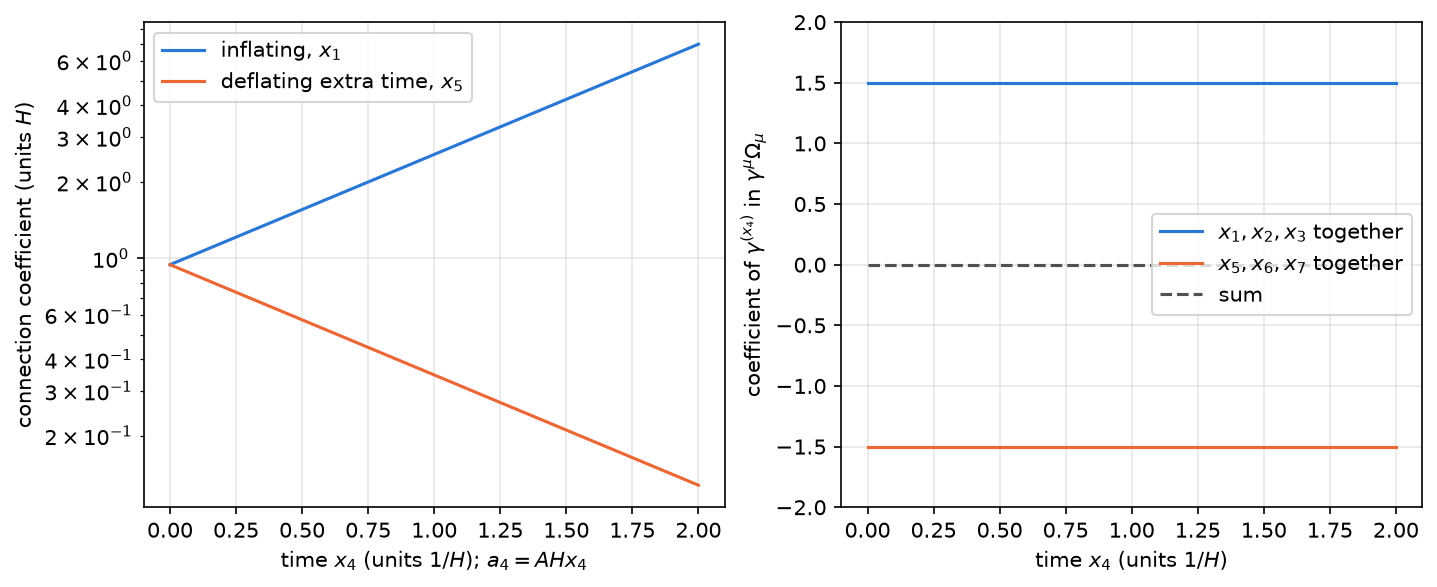

Figure 18b.1 saved as Revision/textbook/figures/18b_1_connection_history.png


In [6]:
params = read_json(PARAMETERS)["physics"]
A_hist, H_hist = params["historyA"], params["H"]  # 1.0 and 1.0
history = {a4: A_hist * H_hist * x4, H: H_hist}  # a4 = A H x4


def along(expr, times, zv=sp.pi / 4):
    """Evaluate expr along the history at the times x4 (numbers for the figure)."""
    e = expr.subs(sp.Derivative(a4, x4), A_hist * H_hist).subs(history)
    f = sp.lambdify(x4, e.subs(z, zv), "numpy")
    return np.broadcast_to(np.asarray(f(times), dtype=float), times.shape)


times = np.linspace(0.0, 2.0, 201)  # x4 from 0 to 2, a4 from 0 to 2
infl = along(patch.om[1, 1, 4], times)
defl = along(-patch.om[5, 4, 5], times)
c_infl = along(3 * coefficient(contributions[1], 4), times)
c_defl = along(3 * coefficient(contributions[5], 4), times)
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2))
axes[0].semilogy(times, infl, color="#2a78d6", label="inflating, $x_1$")
axes[0].semilogy(times, defl, color="#eb6834", label="deflating extra time, $x_5$")
axes[0].set_xlabel("time $x_4$ (units $1/H$); $a_4 = AHx_4$")
axes[0].set_ylabel("connection coefficient (units $H$)")
axes[0].legend()
axes[1].plot(times, c_infl, color="#2a78d6", label="$x_1, x_2, x_3$ together")
axes[1].plot(times, c_defl, color="#eb6834", label="$x_5, x_6, x_7$ together")
axes[1].plot(times, c_infl + c_defl, color="#52514e", linestyle="--", label="sum")
axes[1].set_xlabel("time $x_4$ (units $1/H$)")
axes[1].set_ylabel("coefficient of $\\gamma^{(x_4)}$ in $\\gamma^\\mu\\Omega_\\mu$")
axes[1].set_ylim(-2.0, 2.0)
axes[1].legend(loc="center right")
save_figure(fig, "connection_history",
            "The spin connection of the author's metric along the canonical "
            "deflating history $a_4 = AHx_4$ with $A = 1$, $H = 1$, at $z = \\pi/4$. "
            "Left, logarithmic vertical axis: the coefficient "
            "$a_4^\\prime e^{a_4}\\sin^{1/6}z$ of an inflating 3-space direction "
            "grows and the coefficient $a_4^\\prime e^{-a_4}\\sin^{1/6}z$ of a "
            "deflating extra time decays, both in units of $H$, against the time "
            "$x_4$ in units of $1/H$. Right: their contributions to the "
            "coefficient of $\\gamma^{(x_4)}$ in $\\gamma^\\mu\\Omega_\\mu$, "
            "$+3AH/2$ from the three inflating and $-3AH/2$ from the three "
            "deflating directions, constant in time; their sum, dashed, is zero, "
            "so only $3H\\gamma^{(x_8)}$ survives.")

## 7. An algebra for the jets: commuting or Grassmann

The next cell defines a small algebra of polynomials in numbered generators. An
element is a Python dictionary: each key is a monomial, written as the sorted
tuple of its generator numbers, and each value is its sympy coefficient. Adding
merges the dictionaries. Multiplying multiplies every monomial of the first
factor with every monomial of the second. For COMMUTING generators the product
monomial is just the sorted joined tuple. For GRASSMANN generators (`odd=True`)
two more rules apply: a monomial that contains a generator twice is zero
($\theta\theta = 0$), and sorting the joined tuple costs the sign $(-1)^p$, where
$p$ is the number of pairs that must be exchanged (each exchange of two
anticommuting symbols gives a minus sign). `is_zero` decides whether every
coefficient vanishes, first with `expand` and, if needed, with `simplify`.

In [7]:
class Jet:
    """A polynomial in numbered generators with sympy coefficients."""

    __slots__ = ("terms", "odd")

    def __init__(self, terms, odd):
        self.terms = terms  # {(generator numbers, sorted): coefficient}
        self.odd = odd  # True: Grassmann generators, False: commuting ones

    @staticmethod
    def symbol(number, odd):
        return Jet({(number,): sp.Integer(1)}, odd)

    def __add__(self, other):
        terms = dict(self.terms)
        for key, c in other.terms.items():
            terms[key] = terms[key] + c if key in terms else c
        return Jet(terms, self.odd)

    def __neg__(self):
        return Jet({key: -c for key, c in self.terms.items()}, self.odd)

    def __sub__(self, other):
        return self + (-other)

    def times(self, number):
        """Multiply by a number or a sympy coefficient."""
        if number == 0:
            return Jet({}, self.odd)
        return Jet({key: number * c for key, c in self.terms.items()}, self.odd)

    def __mul__(self, other):
        terms = {}
        for k1, c1 in self.terms.items():
            for k2, c2 in other.terms.items():
                sign = 1
                if self.odd:
                    if set(k1) & set(k2):  # a generator twice: theta theta = 0
                        continue
                    swaps = sum(1 for p in k1 for q in k2 if p > q)
                    sign = -1 if swaps % 2 else 1  # sorting costs (-1)^swaps
                key = tuple(sorted(k1 + k2))
                c = sign * c1 * c2
                terms[key] = terms[key] + c if key in terms else c
        return Jet(terms, self.odd)

    def derivative(self, number):
        """The left derivative with respect to the generator number."""
        terms = {}
        for key, c in self.terms.items():
            if number not in key:
                continue
            place = key.index(number)
            rest = key[:place] + key[place + 1:]
            if self.odd:  # move the generator to the front first
                c = c if place % 2 == 0 else -c
            else:  # an ordinary power rule
                c = key.count(number) * c
            terms[rest] = terms[rest] + c if rest in terms else c
        return Jet(terms, self.odd)

    def substitute(self, rule):
        """Replace symbols in every coefficient (rule: {old: new})."""
        return Jet({key: c.subs(rule) for key, c in self.terms.items()}, self.odd)

    def is_zero(self):
        """True when every coefficient is exactly zero."""
        for c in self.terms.values():
            e = sp.expand(c)
            if e != 0 and sp.simplify(e) != 0:
                return False
        return True


def zero(odd):
    return Jet({}, odd)


def all_zero(items):
    return all(item.is_zero() for item in items)

The next cell defines the matrix operations on columns of 16 algebra elements
(matrix times column, row times matrix, row times column) and the first jet. The
288 generators are numbered: $\Psi^*_A$ is $A$ ($A = 0, \dots, 15$), $\Psi_A$ is
$16 + A$, $\partial_\mu\Psi^*_A$ is $32 + 16(\mu - 1) + A$ and
$\partial_\mu\Psi_A$ is $160 + 16(\mu - 1) + A$. The function `transform` returns
the jet of the new field $\Psi'(x) = P\Psi(Rx)$: the components are multiplied by
the matrix $P$ (their conjugates by $P^*$), and the derivative along $x_\mu$ gets
the sign `signs[mu]` of the coordinate reflection $R$ (all $+1$ for T1; $-1$ for
$x_8$ in the mirror map of T2).

In [8]:
def mat_vec(M, v, odd):
    """The matrix M times the column v of algebra elements."""
    out = []
    for A in range(16):
        acc = zero(odd)
        for B in range(16):
            if M[A, B] != 0:
                acc = acc + v[B].times(M[A, B])
        out.append(acc)
    return out


def row_mat(v, M, odd):
    """The row v of algebra elements times the matrix M."""
    out = []
    for B in range(16):
        acc = zero(odd)
        for A in range(16):
            if M[A, B] != 0:
                acc = acc + v[A].times(M[A, B])
        out.append(acc)
    return out


def dot(u, v, odd):
    """The row u times the column v (the order of the factors is kept)."""
    acc = zero(odd)
    for p, q in zip(u, v):
        if p.terms and q.terms:
            acc = acc + p * q
    return acc


def number_psi_star(A):
    return A


def number_psi(A):
    return 16 + A


def number_dpsi_star(mu, A):
    return 32 + 16 * (mu - 1) + A


def number_dpsi(mu, A):
    return 160 + 16 * (mu - 1) + A


def jets(odd):
    """The first jet (Psi^*, Psi, d Psi^*, d Psi) as algebra generators."""
    return ([Jet.symbol(number_psi_star(A), odd) for A in range(16)],
            [Jet.symbol(number_psi(A), odd) for A in range(16)],
            {mu: [Jet.symbol(number_dpsi_star(mu, A), odd) for A in range(16)]
             for mu in range(1, 9)},
            {mu: [Jet.symbol(number_dpsi(mu, A), odd) for A in range(16)]
             for mu in range(1, 9)})


NO_REFLECTION = {mu: 1 for mu in range(1, 9)}
MIRROR = {mu: (-1 if mu == 8 else 1) for mu in range(1, 9)}  # x8 -> const - x8


def transform(J, P, signs, odd):
    """The jet of Psi'(x) = P Psi(R x)."""
    psi_star, psi, dpsi_star, dpsi = J
    Pc = P.conjugate()
    return (mat_vec(Pc, psi_star, odd), mat_vec(P, psi, odd),
            {mu: [x.times(signs[mu]) for x in mat_vec(Pc, dpsi_star[mu], odd)]
             for mu in range(1, 9)},
            {mu: [x.times(signs[mu]) for x in mat_vec(P, dpsi[mu], odd)]
             for mu in range(1, 9)})

## 8. The Lagrangian, the field equation, $T_{\mu\nu}$ and $J^\mu$ on the jet

The next cell writes the quantities of section 4 on a jet `J` in a geometry
`geo`, line by line as in the formulas: the covariant derivatives
$D_\mu\Psi = \partial_\mu\Psi + \Omega_\mu\Psi$ and $D_\mu\bar\Psi =
(\partial_\mu\Psi^*)^TC - \Psi^{*T}C\Omega_\mu$; the scalar $S = \Psi^{*T}C\Psi$;
the Lagrangian (its argument `upoly`, used once, replaces $\frac{\lambda}{2}S^2$ by
a general cubic $U(S) = u_1S + u_2S^2 + u_3S^3$); the field-equation operator
$E$; the energy-momentum tensor $T_{\mu\nu}$ for $\mu \le \nu$ (36 components);
the current $J^\mu$; and the Euler-Lagrange expressions derived from the
Lagrangian. The derivation uses the rule $\partial_\mu(c\,\Psi_B) =
(\partial_\mu c)\Psi_B + c\,\partial_\mu\Psi_B$ for a coefficient $c$ that
depends on the point (the metric functions).

In [9]:
def covariant(geo, J, odd):
    """D_mu Psi and D_mu Psibar for mu = 1..8."""
    psi_star, psi, dpsi_star, dpsi = J
    Dpsi = {mu: [p + q for p, q in zip(dpsi[mu], mat_vec(geo.Om[mu], psi, odd))]
            for mu in range(1, 9)}
    Dbar = {mu: [p - q for p, q in zip(row_mat(dpsi_star[mu], C, odd),
                                       row_mat(psi_star, C * geo.Om[mu], odd))]
            for mu in range(1, 9)}
    return Dpsi, Dbar


def scalar(J, odd):
    """S = Psibar Psi = Psi^dagger C Psi."""
    return dot(J[0], mat_vec(C, J[1], odd), odd)


def lagrangian(geo, J, odd, mass, coup, upoly=None, density=True):
    """L = sqrt|g| [ K - m S - U(S) ] (density=False: without sqrt|g|)."""
    Dpsi, Dbar = covariant(geo, J, odd)
    kin = zero(odd)
    for mu in range(1, 9):
        kin = kin + dot(J[0], mat_vec(C * geo.gup[mu], Dpsi[mu], odd), odd)
        kin = kin - dot(Dbar[mu], mat_vec(geo.gup[mu], J[1], odd), odd)
    S = scalar(J, odd)
    L = kin.times(sp.Rational(1, 2)) - S.times(mass)
    if upoly is None:  # U = (lambda/2) S^2
        L = L - (S * S).times(coup / 2)
    else:  # U = u1 S + u2 S^2 + u3 S^3
        L = L - S.times(upoly[1]) - (S * S).times(upoly[2])
        L = L - (S * S * S).times(upoly[3])
    return L.times(geo.sqrtg) if density else L


def field_operator(geo, J, odd, mass, coup):
    """E = gamma^mu D_mu Psi - (m + lambda S) Psi (16 algebra elements)."""
    Dpsi, _ = covariant(geo, J, odd)
    S = scalar(J, odd)
    out = [zero(odd) for _ in range(16)]
    for mu in range(1, 9):
        out = [p + q for p, q in zip(out, mat_vec(geo.gup[mu], Dpsi[mu], odd))]
    return [out[A] - J[1][A].times(mass) - (S * J[1][A]).times(coup)
            for A in range(16)]


def emt(geo, J, odd, mass, coup):
    """T_mu nu for mu <= nu (36 components)."""
    Dpsi, Dbar = covariant(geo, J, odd)
    L = lagrangian(geo, J, odd, mass, coup, density=False)
    T = {}
    for mu in range(1, 9):
        for nu in range(mu, 9):
            t = (dot(J[0], mat_vec(C * geo.glow[mu], Dpsi[nu], odd), odd)
                 + dot(J[0], mat_vec(C * geo.glow[nu], Dpsi[mu], odd), odd)
                 - dot(Dbar[mu], mat_vec(geo.glow[nu], J[1], odd), odd)
                 - dot(Dbar[nu], mat_vec(geo.glow[mu], J[1], odd), odd))
            t = t.times(sp.Rational(1, 4))
            if mu == nu:
                t = t - L.times(geo.g[mu])
            T[mu, nu] = t
    return T


def current(geo, J, odd):
    """J^mu = i Psibar gamma^mu Psi (8 components)."""
    return {mu: dot(J[0], mat_vec(sp.I * C * geo.gup[mu], J[1], odd), odd)
            for mu in range(1, 9)}


def euler_lagrange(geo, J, odd, mass, coup):
    """dL/dPsi^*_A - sum_mu d_mu (dL/d(d_mu Psi^*_A)), A = 0..15."""
    L = lagrangian(geo, J, odd, mass, coup)
    out = []
    for A in range(16):
        e = L.derivative(number_psi_star(A))
        for mu in range(1, 9):
            q = L.derivative(number_dpsi_star(mu, A))  # c Psi_B, linear in Psi
            for key, c in q.terms.items():
                B = key[0] - 16  # the component Psi_B of this term
                e = e - Jet({key: d(c, mu)}, odd)  # (d_mu c) Psi_B
                e = e - Jet({(number_dpsi(mu, B),): c}, odd)  # c d_mu Psi_B
        out.append(e)
    return out

## 9. Theorem T1 in the author's metric, both fields

The next cell defines the complete T1 test for one statistics and runs it for
commuting components (dirac16complex00). With $\Psi' = \Gamma\Psi$ (the jet
transformed by $\Gamma$, no coordinate change) it checks, each as an identity in
the 288 jet values:

1. $S[\Gamma\Psi] - S[\Psi] = 0$;
2. $\mathcal{L}_{m,\lambda}[\Gamma\Psi] + \mathcal{L}_{-m,-\lambda}[\Psi] = 0$,
   and it counts the monomials of $\mathcal{L}$ with a nonzero coefficient (the
   Wolfram report records this count);
3. negative controls: $\mathcal{L}_{m,\lambda}[\Gamma\Psi] +
   \mathcal{L}_{m,\lambda}[\Psi] \neq 0$ and $\mathcal{L}_{m,\lambda}[\Gamma\Psi] +
   \mathcal{L}_{-m,\lambda}[\Psi] \neq 0$ (the mass AND the coupling must change
   sign);
4. the Euler-Lagrange expressions derived from $\mathcal{L}$ equal
   $\sqrt{|g|}\,[CE_{m,\lambda}]_A$ for all 16 $A$ (so $E = 0$ IS the field
   equation);
5. $E_{m,\lambda}[\Gamma\Psi] + \Gamma E_{-m,-\lambda}[\Psi] = 0$ (16 components):
   $\Gamma\Psi$ solves the $(m, \lambda)$ equations exactly when $\Psi$ solves
   the $(-m, -\lambda)$ equations;
6. $T_{\mu\nu}[\Gamma\Psi; m, \lambda] + T_{\mu\nu}[\Psi; -m, -\lambda] = 0$ and,
   for the pair, $T_{\mu\nu}[\Psi; m, \lambda] + T_{\mu\nu}[\Gamma\Psi; -m,
   -\lambda] = 0$ (36 components each);
7. $J^\mu[\Gamma\Psi] + J^\mu[\Psi] = 0$ (8 components).

The cell also stores the monomial counts used by the figures. To count the
nonzero coefficients quickly it evaluates each coefficient at one point with
numbers (an exact zero gives 0; this count is a description, not a proof).

In [10]:
SAMPLE = {z: sp.Rational(7, 10), H: sp.Rational(13, 10), m: sp.Rational(11, 10),
          lam: sp.Rational(3, 5)}  # a sample point for counting only
SAMPLE_A4 = {"a4p": sp.Rational(9, 10), "a4": sp.Rational(2, 5)}


def count_nonzero(element):
    """The number of monomials whose coefficient is not zero at the sample."""
    n = 0
    for c in element.terms.values():
        c = c.subs(sp.Derivative(a4, x4), SAMPLE_A4["a4p"])  # a4' first,
        c = c.subs(a4, SAMPLE_A4["a4"]).subs(SAMPLE)  # then a4 and the rest
        value = complex(sp.N(c, 30))
        n += abs(value) > 1e-20
    return n


COUNTS = {}  # the monomial counts for the figures


def t1_checks(odd):
    stat = "grassmann" if odd else "commuting"
    field = "dirac16complex" if odd else "dirac16complex00"
    tag = f"primordial_{stat}"
    J = jets(odd)
    JG = transform(J, GAM, NO_REFLECTION, odd)
    s_ok = (scalar(JG, odd) - scalar(J, odd)).is_zero()
    L_image = lagrangian(patch, JG, odd, m, lam)
    L_plain = lagrangian(patch, J, odd, m, lam)
    L_partner = lagrangian(patch, J, odd, -m, -lam)
    L_wrong = lagrangian(patch, J, odd, -m, lam)
    n_L = count_nonzero(L_plain)
    COUNTS[stat] = {"L": n_L, "L[Gamma Psi]": count_nonzero(L_image),
                    "T1 sum": count_nonzero(L_image + L_partner),
                    "control (m, l)": count_nonzero(L_image + L_plain),
                    "control (-m, l)": count_nonzero(L_image + L_wrong)}
    wl_count = f"L has {n_L} monomials" in recorded(WL, f"T1_Lagrangian_{tag}")[
        "detail"]
    report(f"{field}: monomials of L with a nonzero coefficient", n_L)
    reproduces(s_ok and (L_image + L_partner).is_zero() and wl_count,
               f"T1 {field}: S kept, L_m,l[Gamma Psi] = -L_-m,-l[Psi]",
               (PY, [f"T1.metric.{stat}.S_invariant", f"T1.metric.{stat}.lagrangian"]),
               (WL, [f"T1_scalar_and_kinetic_{tag}", f"T1_Lagrangian_{tag}"]))
    controls = (not (L_image + L_plain).is_zero()
                and not (L_image + L_wrong).is_zero())
    reproduces(controls, f"T1 {field}: the negative controls fail as they must",
               (PY, [f"T1.metric.{stat}.negative_controls"]),
               (WL, [f"T1_Lagrangian_negative_controls_{tag}"]))
    E = field_operator(patch, J, odd, m, lam)
    CE = mat_vec(C, E, odd)
    EL = euler_lagrange(patch, J, odd, m, lam)
    derived = all_zero([EL[A] - CE[A].times(patch.sqrtg) for A in range(16)])
    E_image = field_operator(patch, JG, odd, m, lam)
    E_partner = mat_vec(GAM, field_operator(patch, J, odd, -m, -lam), odd)
    mapped = all_zero([E_image[A] + E_partner[A] for A in range(16)])
    reproduces(derived and mapped,
               f"T1 {field}: EL = sqrt|g| C E; E_m,l[Gamma Psi] = -Gamma E_-m,-l",
               (PY, [f"T1.metric.{stat}.euler_lagrange_derived",
                     f"T1.metric.{stat}.euler_lagrange_map"]),
               (WL, [f"T1_Euler_Lagrange_derived_{tag}",
                     f"T1_field_equation_covariance_{tag}"]))
    T_image = emt(patch, JG, odd, m, lam)
    T_partner = emt(patch, J, odd, -m, -lam)
    T_plain = emt(patch, J, odd, m, lam)
    T_pair = emt(patch, JG, odd, -m, -lam)
    emt_ok = all_zero([T_image[k] + T_partner[k] for k in T_image])
    pair_ok = all_zero([T_plain[k] + T_pair[k] for k in T_plain])
    COUNTS[stat]["T"] = {k: count_nonzero(T_plain[k]) for k in T_plain}
    COUNTS[stat]["T1 sign"] = {k: -1 for k in T_plain if emt_ok}
    J_image, J_plain = current(patch, JG, odd), current(patch, J, odd)
    current_ok = all_zero([J_image[mu] + J_plain[mu] for mu in range(1, 9)])
    reproduces(emt_ok and pair_ok and current_ok and len(T_image) == 36,
               f"T1 {field}: T -> -T (36), pair T sum 0, J -> -J (8)",
               (PY, [f"T1.metric.{stat}.emt", f"T1.metric.{stat}.pair_total_emt_zero",
                     f"T1.metric.{stat}.current"]),
               (WL, [f"T1_energy_momentum_{tag}", f"T1_current_{tag}"]))


t1_checks(False)  # dirac16complex00: commuting components

RESULT dirac16complex00: monomials of L with a nonzero coefficient = 408
PASS T1 dirac16complex00: S kept, L_m,l[Gamma Psi] = -L_-m,-l[Psi]
     reproduces Revision/pairing/reports/python-pairing.json, check
    T1.metric.commuting.S_invariant, T1.metric.commuting.lagrangian;
    Revision/pairing/reports/wolfram-pairing.json, check
    T1_scalar_and_kinetic_primordial_commuting, T1_Lagrangian_primordial_commuting
PASS T1 dirac16complex00: the negative controls fail as they must
     reproduces Revision/pairing/reports/python-pairing.json, check
    T1.metric.commuting.negative_controls; Revision/pairing/reports/wolfram-pairing.json,
    check T1_Lagrangian_negative_controls_primordial_commuting
PASS T1 dirac16complex00: EL = sqrt|g| C E; E_m,l[Gamma Psi] = -Gamma E_-m,-l
     reproduces Revision/pairing/reports/python-pairing.json, check
    T1.metric.commuting.euler_lagrange_derived, T1.metric.commuting.euler_lagrange_map;
    Revision/pairing/reports/wolfram-pairing.json, check
    T

The next cell runs the same test with Grassmann components (dirac16complex).
Because $\Gamma$ only multiplies each component by $+1$ or $-1$, no two
anticommuting factors are ever exchanged by the map, and all checks pass in the
same way; the Lagrangian has fewer monomials, because every monomial of $S^2$ that
contains one generator twice vanishes ($\theta\theta = 0$).

In [11]:
t1_checks(True)  # dirac16complex: Grassmann components
say("monomials of L with a nonzero coefficient: commuting "
    f"{COUNTS['commuting']['L']}, Grassmann {COUNTS['grassmann']['L']}")

RESULT dirac16complex: monomials of L with a nonzero coefficient = 392
PASS T1 dirac16complex: S kept, L_m,l[Gamma Psi] = -L_-m,-l[Psi]
     reproduces Revision/pairing/reports/python-pairing.json, check
    T1.metric.grassmann.S_invariant, T1.metric.grassmann.lagrangian;
    Revision/pairing/reports/wolfram-pairing.json, check
    T1_scalar_and_kinetic_primordial_grassmann, T1_Lagrangian_primordial_grassmann
PASS T1 dirac16complex: the negative controls fail as they must
     reproduces Revision/pairing/reports/python-pairing.json, check
    T1.metric.grassmann.negative_controls; Revision/pairing/reports/wolfram-pairing.json,
    check T1_Lagrangian_negative_controls_primordial_grassmann
PASS T1 dirac16complex: EL = sqrt|g| C E; E_m,l[Gamma Psi] = -Gamma E_-m,-l
     reproduces Revision/pairing/reports/python-pairing.json, check
    T1.metric.grassmann.euler_lagrange_derived, T1.metric.grassmann.euler_lagrange_map;
    Revision/pairing/reports/wolfram-pairing.json, check
    T1_Euler_

The next cell adds two more T1 tests. (a) A general potential: with
$U(S) = u_1S + u_2S^2 + u_3S^3$ (three arbitrary coefficients),
$\mathcal{L}_{m,U}[\Gamma\Psi] + \mathcal{L}_{-m,-U}[\Psi] = 0$, for both
statistics. (b) A general gravitational field, not the author's: an arbitrary
non-diagonal vielbein and an arbitrary connection at one point, made of random
fractions with the fixed seed 20261001 of the Revision report (64 entries
$e^\mu{}_a$, 28 independent $\omega_{\mu ab}$ for each $\mu$, and
$\sqrt{|g|}$), where the Lagrangian identity and the map of the field operator
must hold too, for both statistics.

In [12]:
u1, u2, u3 = sp.symbols("u1 u2 u3", real=True)
cubic_ok = True
for odd in (False, True):
    J = jets(odd)
    JG = transform(J, GAM, NO_REFLECTION, odd)
    L1 = lagrangian(patch, JG, odd, m, 0, upoly={1: u1, 2: u2, 3: u3})
    L2 = lagrangian(patch, J, odd, -m, 0, upoly={1: -u1, 2: -u2, 3: -u3})
    cubic_ok = cubic_ok and (L1 + L2).is_zero()
reproduces(cubic_ok, "T1 with a general cubic potential: L_m,U[Gamma Psi] = "
           "-L_-m,-U[Psi]", (PY, ["T1.metric.commuting.general_potential",
                                  "T1.metric.grassmann.general_potential"]))

rng = random.Random(20261001)  # the seed of the Revision report


def fraction():
    return sp.Rational(rng.randint(-9, 9), rng.randint(1, 5))


class RandomField:
    """A general gravitational field at one point (only what L and E use)."""


field = RandomField()
E8 = [[fraction() for _ in range(8)] for _ in range(8)]  # e^mu_a, not diagonal
field.gup = {mu: sum((E8[mu - 1][a - 1] * G[a] for a in range(1, 9)), sp.zeros(16))
             for mu in range(1, 9)}
field.Om = {}
for mu in range(1, 9):
    M = sp.zeros(16)
    for a in range(1, 9):
        for b in range(a + 1, 9):
            M += fraction() * SAB[a, b]  # an antisymmetric omega
    field.Om[mu] = M
field.sqrtg = abs(fraction()) + 1
random_ok = True
for odd in (False, True):
    J = jets(odd)
    JG = transform(J, GAM, NO_REFLECTION, odd)
    L_sum = (lagrangian(field, JG, odd, m, lam)
             + lagrangian(field, J, odd, -m, -lam))
    E1 = field_operator(field, JG, odd, m, lam)
    E2 = mat_vec(GAM, field_operator(field, J, odd, -m, -lam), odd)
    random_ok = random_ok and all_zero([L_sum] + [E1[A] + E2[A] for A in range(16)])
reproduces(random_ok, "T1 in a random general field (seed 20261001), both fields",
           (PY, ["T1.general_field.random_instance.commuting",
                 "T1.general_field.random_instance.grassmann"]))

PASS T1 with a general cubic potential: L_m,U[Gamma Psi] = -L_-m,-U[Psi]
     reproduces Revision/pairing/reports/python-pairing.json, check
    T1.metric.commuting.general_potential, T1.metric.grassmann.general_potential
PASS T1 in a random general field (seed 20261001), both fields
     reproduces Revision/pairing/reports/python-pairing.json, check
    T1.general_field.random_instance.commuting,
    T1.general_field.random_instance.grassmann


The next cell draws what cancels. For each statistics it shows five bars: the
number of monomials (with a nonzero coefficient) of $\mathcal{L}_{m,\lambda}
[\Psi]$ and of $\mathcal{L}_{m,\lambda}[\Gamma\Psi]$; of the T1 sum
$\mathcal{L}_{m,\lambda}[\Gamma\Psi] + \mathcal{L}_{-m,-\lambda}[\Psi]$ (zero);
and of the two negative controls, where the mass term and the $S^2$ term (first
control) or only the $S^2$ term (second control) survive.

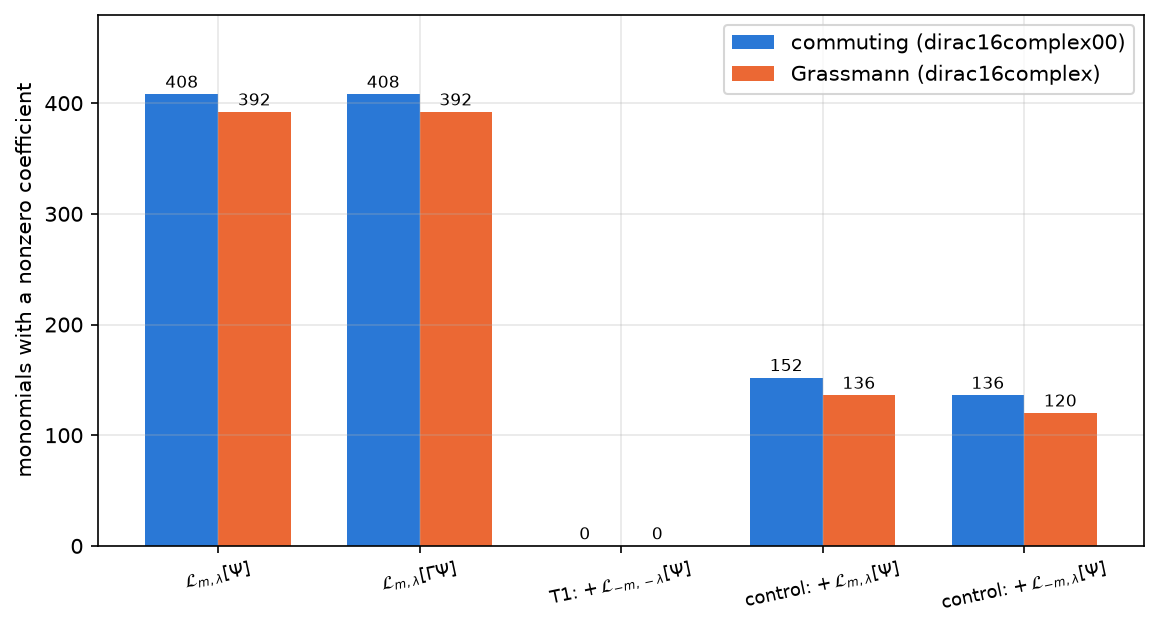

Figure 18b.2 saved as Revision/textbook/figures/18b_2_lagrangian_cancellation.png


In [13]:
labels = ["L", "L[Gamma Psi]", "T1 sum", "control (m, l)", "control (-m, l)"]
texts = ["$\\mathcal{L}_{m,\\lambda}[\\Psi]$",
         "$\\mathcal{L}_{m,\\lambda}[\\Gamma\\Psi]$",
         "T1: $+\\,\\mathcal{L}_{-m,-\\lambda}[\\Psi]$",
         "control: $+\\,\\mathcal{L}_{m,\\lambda}[\\Psi]$",
         "control: $+\\,\\mathcal{L}_{-m,\\lambda}[\\Psi]$"]
fig, ax = plt.subplots(figsize=(9.0, 4.6))
xs = np.arange(len(labels))
for shift, stat, colour in [(-0.18, "commuting", "#2a78d6"),
                            (0.18, "grassmann", "#eb6834")]:
    values = [COUNTS[stat][k] for k in labels]
    ax.bar(xs + shift, values, width=0.36, color=colour,
           label="commuting (dirac16complex00)" if stat == "commuting"
           else "Grassmann (dirac16complex)")
    for x, v in zip(xs + shift, values):
        ax.text(x, v + 6, str(v), ha="center", fontsize=8)
ax.set_xticks(xs, texts, fontsize=8.5, rotation=12)
ax.set_ylabel("monomials with a nonzero coefficient")
ax.set_ylim(0, 480)
ax.legend(loc="upper right")
save_figure(fig, "lagrangian_cancellation",
            "What cancels in theorem T1, in the author's metric with an arbitrary "
            "deflating history. Vertical axis: the number of monomials in the 288 "
            "jet values whose coefficient is not zero. The first two bars of each "
            "colour: the Lagrangian of a field and of its chirality image, "
            "$408$ monomials for commuting components and $392$ for Grassmann "
            "components. Third: the T1 sum with the reversed mass and coupling, "
            "exactly zero. Fourth and fifth, the negative controls: with the "
            "same mass and coupling the mass term and the $S^2$ term survive; "
            "with only the mass reversed the $S^2$ term survives. So both $m$ and "
            "$\\lambda$ must change sign.")

The next cell draws the 36 components of the energy-momentum tensor. Left: the
number of monomials of each component $T_{\mu\nu}[\Psi; m, \lambda]$ of a field
with commuting components (the table is symmetric, $T_{\nu\mu} = T_{\mu\nu}$, and
is drawn in full). Right: the sign $s$ with $T_{\mu\nu}[\Gamma\Psi; -m, -\lambda]
= s\,T_{\mu\nu}[\Psi; m, \lambda]$, which the cell above proved to be $-1$ for
every component: the T1 partner carries exactly the opposite energy density,
momentum density and pressures.

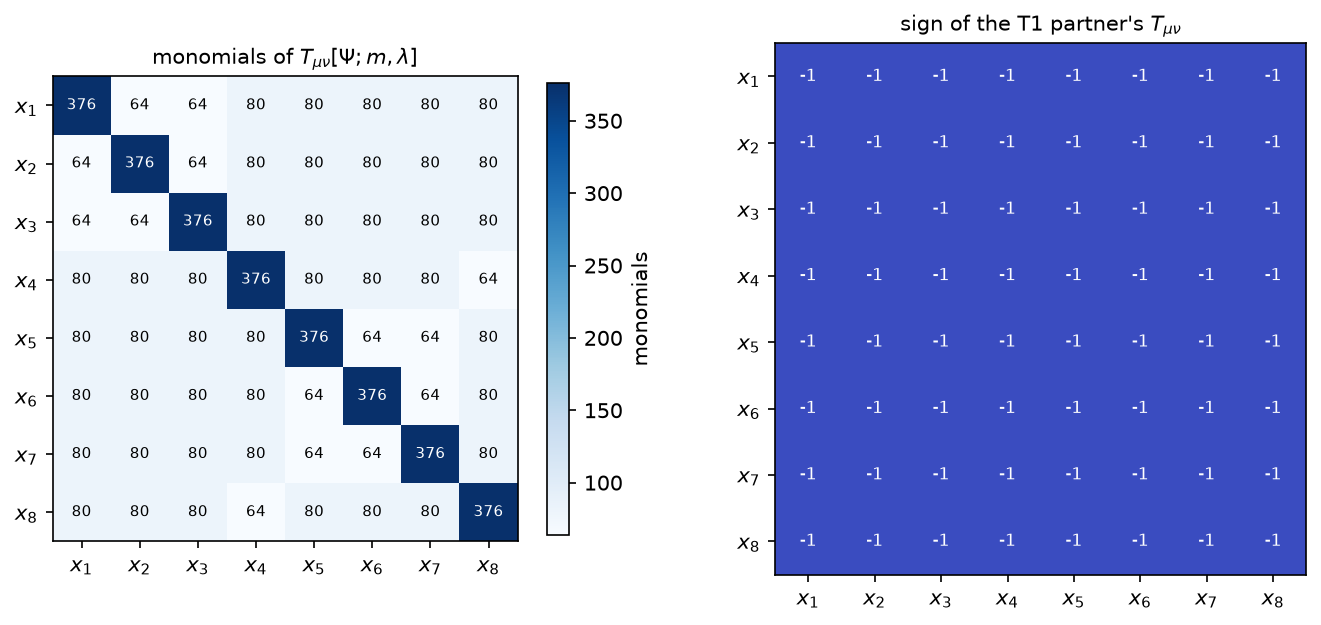

Figure 18b.3 saved as Revision/textbook/figures/18b_3_emt_signs.png


In [14]:
counts = np.zeros((8, 8))
signs = np.zeros((8, 8))
for (mu, nu), n in COUNTS["commuting"]["T"].items():
    counts[mu - 1, nu - 1] = counts[nu - 1, mu - 1] = n
for (mu, nu), s in COUNTS["commuting"]["T1 sign"].items():
    signs[mu - 1, nu - 1] = signs[nu - 1, mu - 1] = s
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.6))
image = axes[0].imshow(counts, cmap="Blues")
fig.colorbar(image, ax=axes[0], shrink=0.85, label="monomials")
axes[1].imshow(signs, cmap="coolwarm", vmin=-1, vmax=1)
for i in range(8):
    for j in range(8):
        axes[0].text(j, i, str(int(counts[i, j])), ha="center", va="center",
                     fontsize=7, color="black" if counts[i, j] < 200 else "white")
        axes[1].text(j, i, f"{int(signs[i, j]):+d}", ha="center", va="center",
                     fontsize=8, color="white")
for ax, title in [(axes[0], "monomials of $T_{\\mu\\nu}[\\Psi; m, \\lambda]$"),
                  (axes[1], "sign of the T1 partner's $T_{\\mu\\nu}$")]:
    ax.set_xticks(range(8), [f"$x_{a}$" for a in range(1, 9)])
    ax.set_yticks(range(8), [f"$x_{a}$" for a in range(1, 9)])
    ax.grid(False)
    ax.set_title(title, fontsize=10)
save_figure(fig, "emt_signs",
            "The 36 independent components of the energy-momentum tensor in the "
            "author's metric, row index $\\mu$ and column index $\\nu$ from $x_1$ "
            "to $x_8$. Left: the number of jet monomials in each component for a "
            "field with commuting components; the diagonal components carry the "
            "whole Lagrangian, the off-diagonal ones only kinetic terms. Right: "
            "the sign that relates the component of the T1 partner "
            "$\\Gamma\\Psi$ with $(-m, -\\lambda)$ to that of $\\Psi$ with "
            "$(m, \\lambda)$, proved to be $-1$ everywhere: energy density, "
            "momentum densities and pressures are all reversed, and the pair has "
            "a zero total.")

## 10. Theorem T2: the mirror across the brane $z = \pi/2$

The next cell builds the mirror patch $\pi/2 < z < \pi$ with its own positive
vielbein ($f_8 = -\cot z > 0$ there) and the patch geometry *evaluated at the
mirror point*: every coefficient function of the patch with $z$ replaced by
$\pi - z$. It checks that $z \to \pi - z$ (that is, $x_8 \to \pi/(6H) - x_8$) is
an isometry, $g_{\mu\mu}(\pi - z) = g_{\mu\mu}(z)$ for all eight components, and
that the brane is a degenerate surface: $g_{88} \to 0$ and $\sqrt{|g|} \to 0$ as
$z \to \pi/2$. Finally it checks the mirror patch's own connection (antisymmetry
and the vielbein postulate).

In [15]:
mirror = Geometry(-1)  # the mirror patch pi/2 < z < pi, f8 = -cot z > 0
to_mirror = {z: sp.pi - z}


class Reflected:
    """The patch's coefficient functions evaluated at the mirror point pi - z."""


reflected = Reflected()
reflected.sqrtg = sp.expand(patch.sqrtg.subs(to_mirror))
reflected.g = {mu: sp.expand(patch.g[mu].subs(to_mirror)) for mu in range(1, 9)}
for name in ("Om", "gup", "glow"):
    setattr(reflected, name, {mu: getattr(patch, name)[mu].subs(to_mirror)
                              .applyfunc(sp.expand) for mu in range(1, 9)})
isometry = all(sp.simplify(patch.g[mu].subs(to_mirror) - patch.g[mu]) == 0
               for mu in range(1, 9))
degenerate = (sp.limit(patch.g[8], z, sp.pi / 2) == 0
              and sp.limit(patch.sqrtg, z, sp.pi / 2) == 0)
reproduces(isometry and degenerate, "z -> pi - z is an isometry; the brane "
           "z = pi/2 is degenerate (g88 = 0, sqrt|g| = 0)",
           (PY, ["geometry.mirror_isometry", "geometry.brane_degenerate"]),
           (WL, ["T2_mirror_is_isometry"]))
mirror_postulate = all(
    sp.simplify(mirror.om[mu, a, b] + mirror.om[mu, b, a]) == 0
    for mu, a, b in itertools.product(range(1, 9), repeat=3))
for mu, nu in itertools.product(range(1, 9), repeat=2):
    M = mirror.gup[nu].applyfunc(lambda e: d(e, mu))
    for la in range(1, 9):
        if mirror.chr[nu, mu, la] != 0:
            M = M + mirror.chr[nu, mu, la] * mirror.gup[la]
    M = M + mirror.Om[mu] * mirror.gup[nu] - mirror.gup[nu] * mirror.Om[mu]
    mirror_postulate = mirror_postulate and all(sp.simplify(e) == 0 for e in M)
say(f"sqrt|g| on the mirror patch = {mirror.sqrtg} (positive there, cos z < 0)")
reproduces(mirror_postulate, "the mirror patch's own connection is canonical",
           (WL, ["connection_mirror_patch"]))

PASS z -> pi - z is an isometry; the brane z = pi/2 is degenerate (g88 = 0, sqrt|g| = 0)
     reproduces Revision/pairing/reports/python-pairing.json, check
    geometry.mirror_isometry, geometry.brane_degenerate;
    Revision/pairing/reports/wolfram-pairing.json, check T2_mirror_is_isometry
sqrt|g| on the mirror patch = -cos(z) (positive there, cos z < 0)
PASS the mirror patch's own connection is canonical
     reproduces Revision/pairing/reports/wolfram-pairing.json, check
    connection_mirror_patch


The next cell draws the metric functions on both patches against $z$ from 0 to
$\pi$: they are mirror-symmetric about the brane $z = \pi/2$, where $g_{88}$ and
$\sqrt{|g|}$ vanish.

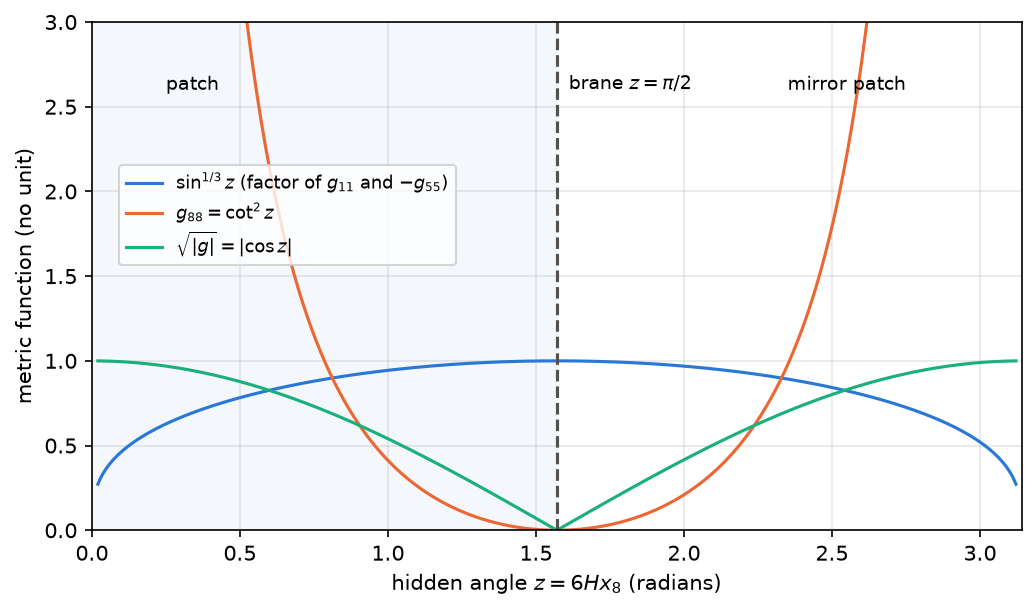

Figure 18b.4 saved as Revision/textbook/figures/18b_4_mirror_metric.png


In [16]:
zs = np.linspace(0.02, np.pi - 0.02, 400)
fig, ax = plt.subplots(figsize=(8.0, 4.4))
ax.plot(zs, np.sin(zs) ** (1.0 / 3.0), color="#2a78d6",
        label="$\\sin^{1/3}z$ (factor of $g_{11}$ and $-g_{55}$)")
ax.plot(zs, 1.0 / np.tan(zs) ** 2, color="#eb6834", label="$g_{88} = \\cot^2 z$")
ax.plot(zs, np.abs(np.cos(zs)), color="#1baf7a", label="$\\sqrt{|g|} = |\\cos z|$")
ax.axvline(np.pi / 2, color="#52514e", linestyle="--")
ax.text(np.pi / 2 + 0.04, 2.6, "brane $z = \\pi/2$", fontsize=9)
ax.axvspan(0.0, np.pi / 2, color="#2a78d6", alpha=0.05)
ax.text(0.25, 2.6, "patch", fontsize=9)
ax.text(2.35, 2.6, "mirror patch", fontsize=9)
ax.set_xlim(0.0, np.pi)
ax.set_ylim(0.0, 3.0)
ax.set_xlabel("hidden angle $z = 6Hx_8$ (radians)")
ax.set_ylabel("metric function (no unit)")
ax.legend(loc="center left", bbox_to_anchor=(0.02, 0.62), fontsize=8.5)
save_figure(fig, "mirror_metric",
            "The functions of the hidden angle that enter the author's metric, "
            "against $z = 6Hx_8$ from 0 to $\\pi$ (horizontal axis, radians; "
            "vertical axis, pure numbers): $\\sin^{1/3}z$, the factor of the "
            "3-space and extra-time components; $g_{88} = \\cot^2 z$; and "
            "$\\sqrt{|g|} = |\\cos z|$. The shaded half is the author's patch, the "
            "other half its mirror patch. Every curve is mirror-symmetric about "
            "the dashed brane $z = \\pi/2$, so $z \\to \\pi - z$ is an isometry. "
            "At the brane $g_{88}$ and $\\sqrt{|g|}$ vanish: the metric is "
            "degenerate there, and gluing the two patches is an assumption.")

The next cell searches, as the sympy report does, for a relation between the
Lagrangian on the mirror patch of the new field $\Psi'(x) = P\Psi(Rx)$ ($R$: the
mirror map, which reverses the derivative along $x_8$) and the Lagrangian on the
patch at the mirror point, $\mathcal{L}^{\rm mirror}_{m,\lambda}[\Psi'] =
\sigma\,\mathcal{L}^{\rm patch}_{\pm m,\pm\lambda}[\Psi]$, with the eight sign
choices of $(\sigma, \pm m, \pm\lambda)$, for the four candidates $P = 1$,
$\Gamma$, $\gamma^{(x_8)}$ and $\Gamma\gamma^{(x_8)}$. The expected answer: no
relation for $P = 1$ and $P = \Gamma$; $P = \gamma^{(x_8)}$ gives
$+\mathcal{L}_{-m,\lambda}$ (theorem T2); $P = \Gamma\gamma^{(x_8)}$ (the
reflection $P_8$ alone) gives $-\mathcal{L}_{m,-\lambda}$.

In [17]:
CANDIDATES = [("1", I16), ("Gamma", GAM), ("gamma^(x8)", G[8]),
              ("Gamma gamma^(x8)", GAM * G[8])]
FOUND = {}
for odd in (False, True):
    J = jets(odd)
    for name, P in CANDIDATES:
        JP = transform(J, P, MIRROR, odd)
        L_mirror = lagrangian(mirror, JP, odd, m, lam)
        hit = None
        for sigma, sm, sl in itertools.product((1, -1), repeat=3):
            L_patch = lagrangian(reflected, J, odd, sm * m, sl * lam)
            if (L_mirror - L_patch.times(sigma)).is_zero():
                hit = (sigma, sm, sl)
                break
        FOUND[odd, name] = hit
for name, _ in CANDIDATES:
    hit = FOUND[False, name]
    text = "no relation" if hit is None else (
        f"L = {'+' if hit[0] > 0 else '-'}L_({'' if hit[1] > 0 else '-'}m, "
        f"{'' if hit[2] > 0 else '-'}lambda)")
    say(f"P = {name}: {text} (the same for Grassmann components: "
        f"{FOUND[True, name] == hit})")
expected = {"1": None, "Gamma": None, "gamma^(x8)": (1, -1, 1),
            "Gamma gamma^(x8)": (-1, 1, -1)}
reproduces(all(FOUND[odd, name] == expected[name]
               for odd in (False, True) for name, _ in CANDIDATES),
           "T2: only gamma^(x8) maps (m, lambda) to (-m, lambda) with L -> +L",
           (PY, ["T2.metric.commuting.reflection_table",
                 "T2.metric.grassmann.reflection_table"]),
           (WL, ["T2_mirror_Lagrangian_commuting", "T2_mirror_Lagrangian_grassmann"]))

P = 1: no relation (the same for Grassmann components: True)
P = Gamma: no relation (the same for Grassmann components: True)
P = gamma^(x8): L = +L_(-m, lambda) (the same for Grassmann components: True)
P = Gamma gamma^(x8): L = -L_(m, -lambda) (the same for Grassmann components: True)
PASS T2: only gamma^(x8) maps (m, lambda) to (-m, lambda) with L -> +L
     reproduces Revision/pairing/reports/python-pairing.json, check
    T2.metric.commuting.reflection_table, T2.metric.grassmann.reflection_table;
    Revision/pairing/reports/wolfram-pairing.json, check T2_mirror_Lagrangian_commuting,
    T2_mirror_Lagrangian_grassmann


The next cell completes T2 for $P = \gamma^{(x_8)}$, both statistics: the field
equations, $E^{\rm mirror}_{m,\lambda}[\Psi'] = -\gamma^{(x_8)}E^{\rm patch}
_{-m,\lambda}[\Psi]$ (so $\Psi$ solves the $(-m, \lambda)$ equations on the patch
exactly when its mirror image solves the $(m, \lambda)$ equations on the mirror
patch); the energy-momentum tensor, $T_{\mu\nu}[\Psi'] = \Lambda_\mu\Lambda_\nu
T_{\mu\nu}[\Psi; -m, \lambda]$ with $\Lambda = \mathrm{diag}(1, 1, 1, 1, 1, 1, 1,
-1)$ (the ordinary change of a tensor under the reflection of $x_8$; no other sign
change, so the energy density is EQUAL); the current, $J'^\mu = \Lambda_\mu
J^\mu$; and $S[\gamma^{(x_8)}\Psi] = -S[\Psi]$. The cell also records the sign of
every component of $T_{\mu\nu}$ for the figure.

In [18]:
t2_ok = True
T2_SIGNS = {}
for odd in (False, True):
    J = jets(odd)
    JP = transform(J, G[8], MIRROR, odd)
    E1 = field_operator(mirror, JP, odd, m, lam)
    E2 = mat_vec(G[8], field_operator(reflected, J, odd, -m, lam), odd)
    el_ok = all_zero([E1[A] + E2[A] for A in range(16)])
    T1_ = emt(mirror, JP, odd, m, lam)
    T2_ = emt(reflected, J, odd, -m, lam)
    emt_ok = all_zero([T1_[k] - T2_[k].times(MIRROR[k[0]] * MIRROR[k[1]])
                       for k in T1_])
    if not odd:
        T2_SIGNS = {k: MIRROR[k[0]] * MIRROR[k[1]] for k in T1_ if emt_ok}
    J1, J2 = current(mirror, JP, odd), current(reflected, J, odd)
    current_ok = all_zero([J1[mu] - J2[mu].times(MIRROR[mu]) for mu in range(1, 9)])
    s_odd = (scalar(JP, odd) + scalar(J, odd)).is_zero()
    stat = "grassmann" if odd else "commuting"
    say(f"{stat}: field equations mapped {el_ok}, T pulled back {emt_ok}, "
        f"J pulled back {current_ok}, S reversed {s_odd}")
    t2_ok = t2_ok and el_ok and emt_ok and current_ok and s_odd
reproduces(t2_ok, "T2: field equations mapped, T and J pulled back (equal energy), "
           "S reversed", (PY, [f"T2.metric.{s}.{c}" for s in ("commuting", "grassmann")
                               for c in ("euler_lagrange_map", "emt", "current",
                                         "S_odd")]),
           (WL, ["T2_mirror_energy_momentum_and_current_commuting",
                 "T2_mirror_energy_momentum_and_current_grassmann",
                 "T2_mirror_Euler_Lagrange_commuting",
                 "T2_mirror_Euler_Lagrange_grassmann"]))

commuting: field equations mapped True, T pulled back True, J pulled back True, S
    reversed True
grassmann: field equations mapped True, T pulled back True, J pulled back True, S
    reversed True
PASS T2: field equations mapped, T and J pulled back (equal energy), S reversed
     reproduces Revision/pairing/reports/python-pairing.json, check
    T2.metric.commuting.euler_lagrange_map, T2.metric.commuting.emt,
    T2.metric.commuting.current, T2.metric.commuting.S_odd,
    T2.metric.grassmann.euler_lagrange_map, T2.metric.grassmann.emt,
    T2.metric.grassmann.current, T2.metric.grassmann.S_odd;
    Revision/pairing/reports/wolfram-pairing.json, check
    T2_mirror_energy_momentum_and_current_commuting,
    T2_mirror_energy_momentum_and_current_grassmann, T2_mirror_Euler_Lagrange_commuting,
    T2_mirror_Euler_Lagrange_grassmann


The next cell draws two summaries of T2. Left: the search of the cell before last
as a grid, one row per candidate matrix $P$ and one column per sign choice
$(\sigma, \pm m, \pm\lambda)$; a filled square marks the relation that holds.
Right: the sign $s$ in $T_{\mu\nu}[\text{mirror image}] = s\,T_{\mu\nu}[\Psi;
-m, \lambda]$, $+1$ except for the seven mixed components with one $x_8$ index.

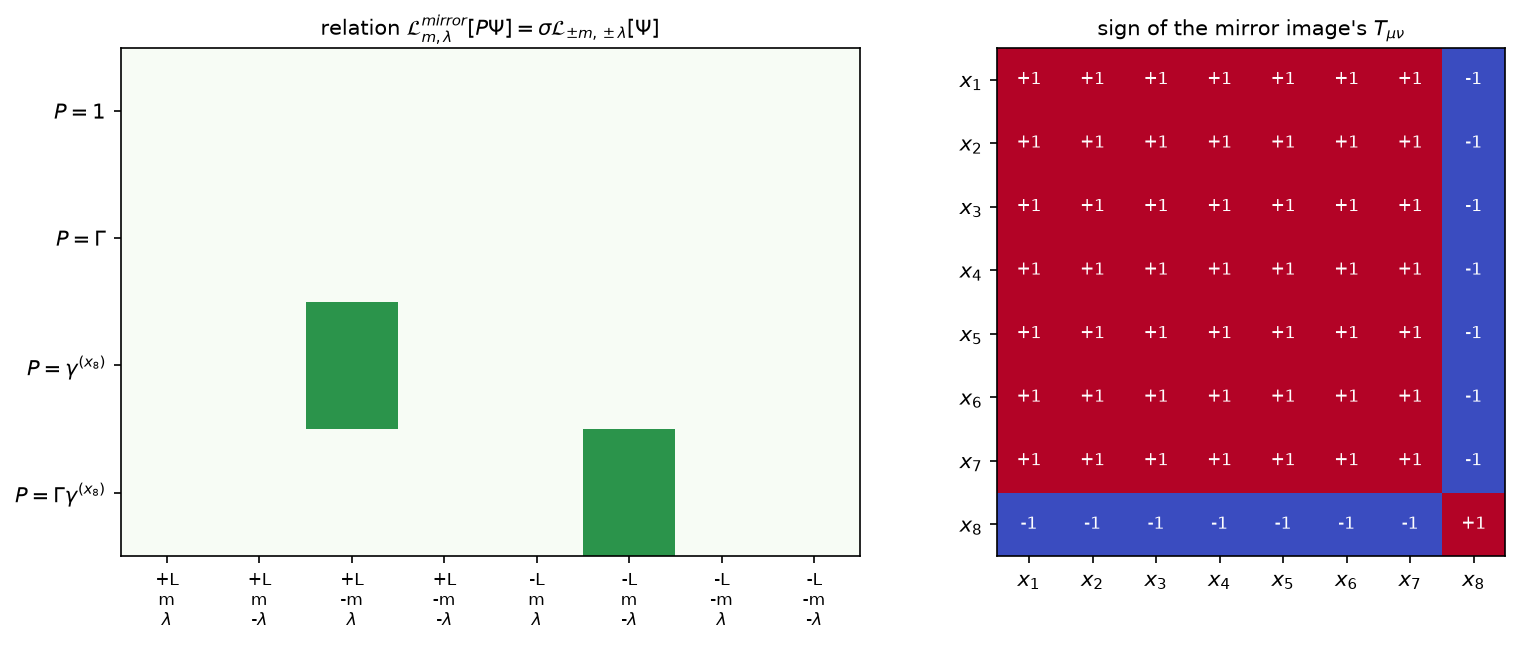

Figure 18b.5 saved as Revision/textbook/figures/18b_5_mirror_candidates.png


In [19]:
choices = list(itertools.product((1, -1), repeat=3))
grid = np.zeros((len(CANDIDATES), len(choices)))
for i, (name, _) in enumerate(CANDIDATES):
    if FOUND[False, name] is not None:
        grid[i, choices.index(FOUND[False, name])] = 1.0
t2_signs = np.zeros((8, 8))
for (mu, nu), s in T2_SIGNS.items():
    t2_signs[mu - 1, nu - 1] = t2_signs[nu - 1, mu - 1] = s
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.4),
                         gridspec_kw={"width_ratios": [1.4, 1.0]})
axes[0].imshow(grid, cmap="Greens", vmin=0, vmax=1.4, aspect="auto")
axes[0].set_xticks(range(len(choices)),
                   [f"{'+' if s > 0 else '-'}L\n{'' if a > 0 else '-'}m\n"
                    f"{'' if b > 0 else '-'}$\\lambda$" for s, a, b in choices],
                   fontsize=8)
axes[0].set_yticks(range(len(CANDIDATES)),
                   ["$P = 1$", "$P = \\Gamma$", "$P = \\gamma^{(x_8)}$",
                    "$P = \\Gamma\\gamma^{(x_8)}$"])
axes[0].set_title("relation $\\mathcal{L}^{mirror}_{m,\\lambda}[P\\Psi] = "
                  "\\sigma\\mathcal{L}_{\\pm m,\\pm\\lambda}[\\Psi]$", fontsize=10)
axes[0].grid(False)
axes[1].imshow(t2_signs, cmap="coolwarm", vmin=-1, vmax=1)
for i in range(8):
    for j in range(8):
        axes[1].text(j, i, f"{int(t2_signs[i, j]):+d}", ha="center", va="center",
                     fontsize=8, color="white")
axes[1].set_xticks(range(8), [f"$x_{a}$" for a in range(1, 9)])
axes[1].set_yticks(range(8), [f"$x_{a}$" for a in range(1, 9)])
axes[1].set_title("sign of the mirror image's $T_{\\mu\\nu}$", fontsize=10)
axes[1].grid(False)
save_figure(fig, "mirror_candidates",
            "Theorem T2 in the author's metric. Left: for four candidate matrices "
            "$P$ (rows), the eight possible relations between the Lagrangian of "
            "the mirror image on the mirror patch and the Lagrangian of $\\Psi$ on "
            "the patch (columns: overall sign $\\sigma$, sign of $m$, sign of "
            "$\\lambda$); a green square marks the relation that holds exactly. "
            "$P = 1$ and $P = \\Gamma$ give none; $P = \\gamma^{(x_8)}$ gives "
            "$+\\mathcal{L}_{-m,\\lambda}$, theorem T2; $P = \\Gamma\\gamma^{(x_8)}$ "
            "gives $-\\mathcal{L}_{m,-\\lambda}$. Right: the sign of each component "
            "of the mirror image's $T_{\\mu\\nu}$ relative to that of the "
            "$(-m, \\lambda)$ field, $+1$ except the mixed components with one "
            "$x_8$ index: the energy density is equal, not opposite.")

## 11. The last check

The last cell checks that the five figure files exist and prints the number of
checks that passed.

In [20]:
figure_names = ["connection_history", "lagrangian_cancellation", "emt_signs",
                "mirror_metric", "mirror_candidates"]
paths = [output_file(f"{FIGURE_FOLDER}/18b_{k}_{name}.png")
         for k, name in enumerate(figure_names, 1)]
check(all(path.is_file() for path in paths),
      "every figure file of this notebook exists")
all_checks_passed()

PASS every figure file of this notebook exists
ALL 20 CHECKS PASSED (notebook 18b)


## 12. What this notebook showed

- PROVED (exact sympy identities in the first jet, for an arbitrary history
  $a_4(x_4)$ of the deflating extra times): the diagonal vielbein gives the
  author's metric with $\sqrt{|g|} = \cos z$; its canonical spin connection has
  exactly the 12 nonzero components of the Revision record and obeys the vielbein
  postulate; $\gamma^\mu\Omega_\mu = 3H\gamma^{(x_8)}$, because the $a_4'$ terms of
  the three inflating directions and of the three deflating extra times cancel.
- PROVED, theorem T1, for dirac16complex00 (commuting) and dirac16complex
  (Grassmann) in the author's metric: $S[\Gamma\Psi] = S[\Psi]$;
  $\mathcal{L}_{m,\lambda}[\Gamma\Psi] = -\mathcal{L}_{-m,-\lambda}[\Psi]$ (the
  Lagrangian has 408, respectively 392, monomials, as in the Wolfram report); the
  Euler-Lagrange expressions are $\sqrt{|g|}\,CE$; $\Gamma\Psi$ solves the
  $(m, \lambda)$ equations exactly when $\Psi$ solves the $(-m, -\lambda)$ ones;
  all 36 components of $T_{\mu\nu}$ and all 8 of $J^\mu$ change sign, so the pair
  has zero total energy-momentum and current as classical bilinears. The negative
  controls fail: both $m$ and $\lambda$ must change sign. The same holds for a
  general cubic potential and in a random general gravitational field.
- PROVED, theorem T2: with the mirror $z \to \pi - z$ (an isometry; the brane
  $z = \pi/2$ is degenerate) and $\Psi \to \gamma^{(x_8)}\Psi$, the Lagrangian of
  the image with $(m, \lambda)$ on the mirror patch equals the Lagrangian of the
  field with $(-m, \lambda)$ on the patch; the field equations are mapped;
  $T_{\mu\nu}$ and $J^\mu$ are pulled back (equal energy density, not opposite)
  and $S$ is reversed. Neither $1$ nor $\Gamma$ gives such a relation.
- ASSUMED: the gluing of the mirror patch to the patch at the degenerate brane
  (the Z2 construction). The gravitational field is a fixed background in both
  theorems; nothing here derives back-reaction.
- NOT shown, and not following from these identities: that any universe is
  created, in pairs or otherwise. T1 and T2 map solutions to solutions; they
  contain no process, rate or amplitude.